# Stage 1 — EDA da base Bank Marketing

**Datathon 7MLET — Grupo 74.** Notebook reprodutível de Análise Exploratória sobre a base processada (sem vazamento).

> Roda offline com o *facsimile* determinístico ou com a base Kaggle real (se baixada — ver `data/kaggle/README.md`).

In [1]:
import sys; sys.path.insert(0, "../src")
import pandas as pd, matplotlib.pyplot as plt
from adaptive_offers.data.preprocessing import build_processed, load_processed
from adaptive_offers.data.quality import quality_report, target_rate_by
pd.set_option("display.width", 120)

## 1. Carregar / construir a base processada
O build registra proveniência (fonte, versão, licença) em `data/processed/provenance.json`.

In [2]:
df, prov, path = build_processed(n_rows=20000)
print("source:", prov.source, "| version:", prov.version, "| license:", prov.license)
df.head()

2026-08-15 20:19:06,360 | INFO    | adaptive_offers.data.loader | {"event": "load_real", "path": "C:\\Users\\Dione\\Desktop\\datathon-7mlet-grupo-74\\datathon-7mlet-grupo-64\\data\\kaggle\\raw\\bank-additional-full.csv"}


2026-08-15 20:19:07,618 | INFO    | adaptive_offers.data.preprocessing | {"event": "processed_built", "ts": "2026-08-15T23:19:07.618214+00:00", "source": "real", "rows": 41188, "cols": 22, "target_rate": 0.1127, "dropped_leakage": ["duration"], "path": "C:\\Users\\Dione\\Desktop\\datathon-7mlet-grupo-74\\datathon-7mlet-grupo-64\\data\\processed\\bank_marketing_processed.parquet"}


source: real | version: UCI bank-additional-full (2014) | license: CC BY 4.0 (UCI Machine Learning Repository / Moro et al., 2014)


,client_event_id,age,job,marital,education,default,housing,loan,contact,month,...,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previously_contacted,pdays_since,subscribed
0,ce_0000000,56,housemaid,married,basic.4y,no,no,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
1,ce_0000001,57,services,married,high.school,unknown,no,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
2,ce_0000002,37,services,married,high.school,no,yes,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
3,ce_0000003,40,admin.,married,basic.6y,no,no,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
4,ce_0000004,56,services,married,high.school,no,no,yes,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0


## 2. Perfil de qualidade
Missingness, cardinalidade, duplicatas e balanceamento do alvo.

In [3]:
rep = quality_report(df)
print("rows:", rep["n_rows"], "cols:", rep["n_cols"], "duplicates:", rep["n_duplicates"])
print("target:", rep["target"])

rows: 41188 cols: 22 duplicates: 0
target: {'name': 'subscribed', 'positive_rate': 0.1127, 'imbalance_ratio': 7.88}


## 3. Balanceamento do alvo `subscribed`
O forte desbalanceamento justifica métricas além de acurácia (uplift/regret) na Etapa 4.

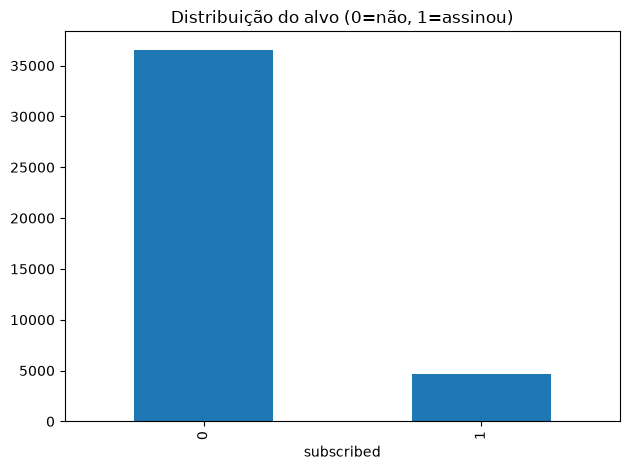

In [4]:
ax = df["subscribed"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição do alvo (0=não, 1=assinou)"); ax.set_xlabel("subscribed"); plt.tight_layout(); plt.show()

## 4. Drivers de conversão
Taxa de assinatura por `poutcome` e por `contact` — sinais que alimentam o contexto do bandit (Etapa 3).

In [5]:
print(target_rate_by(df, "poutcome").to_string())
print()
print(target_rate_by(df, "contact").to_string())

             subscription_rate      n
poutcome                             
success                 0.6511   1373
failure                 0.1423   4252
nonexistent             0.0883  35563

           subscription_rate      n
contact                            
cellular              0.1474  26144
telephone             0.0523  15044


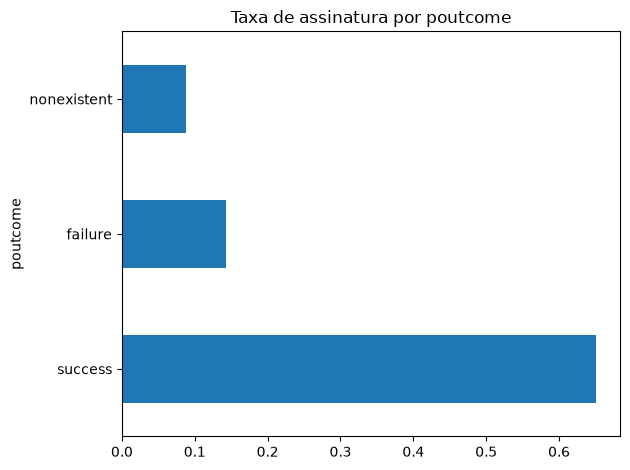

In [6]:
g = target_rate_by(df, "poutcome")
ax = g["subscription_rate"].plot(kind="barh")
ax.set_title("Taxa de assinatura por poutcome"); plt.tight_layout(); plt.show()

## 5. Idade vs. conversão
Clientes nos extremos etários (estudantes/aposentados) tendem a converter mais.

In [7]:
df["age_band"] = pd.cut(df["age"], bins=[17,25,35,45,55,65,100], labels=["18-25","26-35","36-45","46-55","56-65","65+"])
print(target_rate_by(df, "age_band").to_string())

          subscription_rate      n
age_band                          
65+                  0.4685    619
18-25                0.2089   1661
56-65                0.1522   2963
26-35                0.1172  14847
46-55                0.0869   8249
36-45                0.0851  12844


C:\Users\Dione\Desktop\datathon-7mlet-grupo-74\datathon-7mlet-grupo-64\notebooks\../src\adaptive_offers\data\quality.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(by)[target].agg(["mean", "count"]).rename(


## 6. Conclusões
- Sem vazamento (`duration` removida; `pdays` tratado).
- Alvo desbalanceado (~5% facsimile / ~11% real).
- Drivers: `poutcome=success`, canal `cellular`, juros baixos, extremos etários.
- Esses sinais definem o **vetor de contexto** usado pelo LinUCB na decisão de oferta.

Ver `reports/eda-quality-report.md` para o relatório consolidado.

---

## Etapa 3 — Baseline vs. política adaptativa

O edital pede a comparação **aqui no notebook**: a taxa de conversão de uma
regra fixa (baseline) contra a do algoritmo adaptativo.

O baseline é guloso e **não explora**: escolhe sempre o braço de maior valor
estimado. As políticas adaptativas equilibram exploração e explotação.

In [8]:
from adaptive_offers.bootstrap import ensure_bundle, ensure_data
from adaptive_offers.evaluation import metrics_matrix

proc = ensure_data(seed=123)
bundle = ensure_bundle(proc, seed=123)

# Simula cada política sobre os mesmos 6.000 contatos reais.
matriz = metrics_matrix(proc, bundle, horizon=6000)

import pandas as pd
comp = pd.DataFrame(matriz)[
    ["policy", "cumulative_reward", "conversion_rate", "regret_ratio", "lift_vs_baseline_pct"]
]
comp.columns = ["politica", "reward_acumulado", "conversao", "regret_ratio", "lift_vs_baseline_%"]
comp.sort_values("reward_acumulado", ascending=False, ignore_index=True)

2026-08-15 20:19:34,622 | INFO    | adaptive_offers.data.synthetic | {"event": "synthetic_generated", "ts": "2026-08-15T23:19:34.621793+00:00", "seed": 123, "n_arms": 6, "n_events": 41188, "n_delayed": 1151, "conversion_rate": 0.0701, "delayed_share": 0.0279, "out_dir": "C:\\Users\\Dione\\Desktop\\datathon-7mlet-grupo-74\\datathon-7mlet-grupo-64\\data\\synthetic_enrichment"}


2026-08-15 20:19:41,912 | INFO    | adaptive_offers.simulation.environment | {"event": "simulation_done", "policy": "baseline", "rounds": 6000, "cum_reward": 104700.0, "cum_regret": 13029.2}


2026-08-15 20:19:54,237 | INFO    | adaptive_offers.simulation.environment | {"event": "simulation_done", "policy": "thompson", "rounds": 6000, "cum_reward": 114290.0, "cum_regret": 14070.3}


2026-08-15 20:19:59,359 | INFO    | adaptive_offers.simulation.environment | {"event": "simulation_done", "policy": "nilos_ucb", "rounds": 6000, "cum_reward": 102020.0, "cum_regret": 20346.5}


2026-08-15 20:20:06,762 | INFO    | adaptive_offers.simulation.environment | {"event": "simulation_done", "policy": "linucb", "rounds": 6000, "cum_reward": 113230.0, "cum_regret": 9967.2}


,politica,reward_acumulado,conversao,regret_ratio,lift_vs_baseline_%
0,thompson,114290.0,0.0712,0.1176,9.16
1,linucb,113230.0,0.0908,0.0833,8.15
2,baseline,104700.0,0.0623,0.1089,0.00
3,nilos_ucb,102020.0,0.0705,0.1700,-2.56


**Leitura.** O ranqueamento é por **valor** (`P(conversão) × margem`), não por
conversão isolada — é o que o negócio captura de fato.

Repare no baseline: ele aparece com **conversão alta e valor baixo**. Converter
mais no produto de margem menor rende menos. Foi por isso que a recompensa é
ponderada pela margem.

Honestidade sobre o resultado: na base real o ganho é **de um dígito** (~8–9%),
não os +60% que uma base fac-símile produzia. E **nem todo bandit vence** — o
Nilos-UCB fica abaixo do baseline nesta seed.

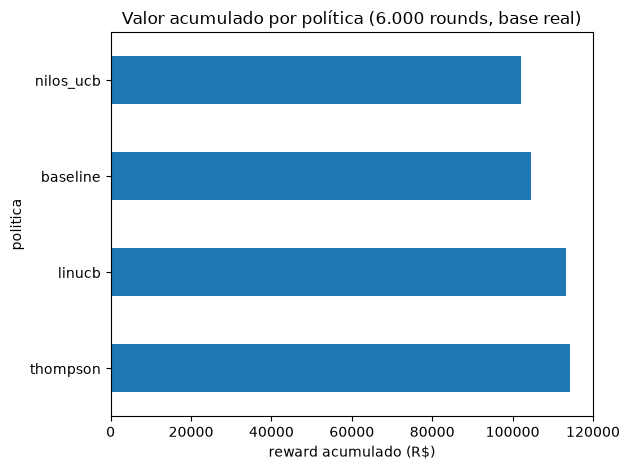

In [9]:
ax = comp.set_index("politica")[["reward_acumulado"]].plot(kind="barh", legend=False)
ax.set_title("Valor acumulado por política (6.000 rounds, base real)")
ax.set_xlabel("reward acumulado (R$)")
plt.tight_layout(); plt.show()

---

## Etapa 4 — Golden set simplificado: 5 clientes

Cinco perfis distintos, a oferta que o modelo recomendou para cada um e se a
decisão faz sentido.

In [10]:
from adaptive_offers.policy.decision_service import DecisionService

svc = DecisionService.from_active()

casos = [
    ("Sênior conservador, contato bem-sucedido antes",
     {"age": 66, "contact": "cellular", "poutcome": "success", "euribor3m": 0.8}),
    ("Jovem digital, primeiro contato",
     {"age": 24, "contact": "cellular", "poutcome": "nonexistent", "euribor3m": 4.9}),
    ("Cliente com empréstimo ativo (elegibilidade restringe)",
     {"age": 45, "contact": "telephone", "poutcome": "failure", "loan": "yes", "euribor3m": 4.9}),
    ("Meia-idade, juros baixos",
     {"age": 52, "contact": "cellular", "poutcome": "success", "euribor3m": 0.7}),
    ("Inadimplente — deve cair no controle (sem oferta)",
     {"age": 38, "contact": "telephone", "poutcome": "failure",
      "default": "yes", "loan": "yes", "euribor3m": 4.9}),
]

linhas = []
for descricao, ctx in casos:
    rec = svc.decide(context=ctx, log=False)
    linhas.append({
        "perfil": descricao,
        "oferta recomendada": rec.arm_name,
        "P(conversão)": f"{rec.expected_p:.1%}",
        "margem": f"R$ {rec.margin:.0f}",
        "valor esperado": f"R$ {rec.expected_reward:.2f}".replace(".", ","),
        "modo": "exploração" if rec.explored else "explotação",
    })

pd.DataFrame(linhas)

,perfil,oferta recomendada,P(conversão),margem,valor esperado,modo
0,"Sênior conservador, contato bem-sucedido antes",Fundo de Investimento Intro,35.3%,R$ 180,"R$ 63,51",explotação
1,"Jovem digital, primeiro contato",Cartão Cashback,27.3%,R$ 120,"R$ 32,75",explotação
2,Cliente com empréstimo ativo (elegibilidade re...,Fundo de Investimento Intro,5.9%,R$ 180,"R$ 10,65",exploração
3,"Meia-idade, juros baixos",Depósito a Prazo Premium,18.2%,R$ 200,"R$ 36,48",exploração
4,Inadimplente — deve cair no controle (sem oferta),Depósito a Prazo Premium,6.9%,R$ 200,"R$ 13,83",exploração


**As decisões fazem sentido?**

| # | Perfil | Oferta | Faz sentido? |
|---|---|---|---|
| 1 | Sênior, sucesso prévio | Fundo de Investimento (R$ 63,51) | ✅ Perfil receptivo e margem alta dão o maior valor esperado |
| 2 | Jovem, primeiro contato | Cartão Cashback (R$ 32,75) | ✅ Sem histórico, produto de entrada em vez de crédito ou investimento |
| 3 | **Com empréstimo ativo** | Fundo — **Empréstimo excluído** | ✅ O gate corta `OFF_LOAN_PREAPP` antes da escolha: sobram 5 braços |
| 4 | Meia-idade, juros baixos | Depósito a Prazo (R$ 36,48) | ✅ Juros baixos favorecem produto de prazo |
| 5 | **Inadimplente** | Depósito — **crédito todo excluído** | ✅ `OFF_LOAN_PREAPP` **e** `OFF_CC_CASHBACK` saem: sobram 4 braços, nenhum de crédito |

O ponto central: **a elegibilidade age antes do bandit**. Nos casos 3 e 5 a
política nunca chega a considerar crédito — os braços saem do conjunto elegível
e a decisão registra `ELIGIBILITY_FILTERED` no log auditável.

> Repare que o caso 5 **não** cai no braço de controle: negar crédito a um
> inadimplente não significa não ter o que oferecer. Um depósito não expõe o
> cliente a mais dívida, então continua elegível — a restrição é de *suitability*
> de crédito, não de contato.